In [2]:
import pandas as pd
df=pd.read_csv('TCS_New.csv')

In [ ]:
df.head(30)

,Price,Close,High,Low,Open,Volume
0,Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
1,Date,NaN,NaN,NaN,NaN,NaN
2,2021-03-03,2689.1845703125,2693.49196181922,2634.505808531232,2667.9987284991294,3509857
3,2021-03-04,2680.9208984375,2708.8315912558814,2651.340045282069,2657.4495870855635,3916760
4,2021-03-05,2644.307861328125,2692.7888765877847,2634.2424716557,2651.38447476698,3203686
5,2021-03-08,2643.34033203125,2666.240328983953,2633.714482570367,2651.2960211723052,2003125
6,2021-03-09,2682.02001953125,2696.0412552244425,2630.28646512969,2643.3406302433177,1942397
7,2021-03-10,2699.601806640625,2719.1612723280527,2689.975955214769,2703.1621118579787,3053778
8,2021-03-12,2688.173583984375,2740.0831259740735,2673.5810339324644,2703.161890397907,2938317
9,2021-03-15,2695.382080078125,2724.2598477579736,2673.2733775514675,2673.2733775514675,3097083


In [5]:
df = pd.read_csv('TCS_New.csv')

df = df.iloc[2:].reset_index(drop=True)

df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

df['Date'] = pd.to_datetime(df['Date'])
df['Close'] = df['Close'].astype(float)

df = df.sort_values('Date')

df.head()

,Date,Close,High,Low,Open,Volume
0,2021-03-03,2689.184570,2693.49196181922,2634.505808531232,2667.9987284991294,3509857
1,2021-03-04,2680.920898,2708.8315912558814,2651.340045282069,2657.4495870855635,3916760
2,2021-03-05,2644.307861,2692.7888765877847,2634.2424716557,2651.38447476698,3203686
3,2021-03-08,2643.340332,2666.240328983953,2633.714482570367,2651.2960211723052,2003125
4,2021-03-09,2682.020020,2696.0412552244425,2630.28646512969,2643.3406302433177,1942397


In [6]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [7]:
data = df[['Close']].values

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [9]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

In [10]:
def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

time_step = 60
X, y = create_dataset(scaled_data, time_step)

In [11]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [12]:
model = Sequential()

model.add(LSTM(units=50, return_sequences=True, input_shape=(X.shape[1], 1)))
model.add(Dropout(0.2))

model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 0.0306 - val_loss: 0.0104
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0071 - val_loss: 0.0038
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0056 - val_loss: 0.0034
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0052 - val_loss: 0.0039
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0048 - val_loss: 0.0030
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0047 - val_loss: 0.0030
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0045 - val_loss: 0.0028
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0046 - val_loss: 0.0025
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0043 - val_loss: 0.0025
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0042 - val_loss: 0.0025
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0046 - val_loss: 0.0050
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0

In [14]:
predictions = model.predict(X_test)

# Inverse transform
predictions = scaler.inverse_transform(predictions.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step


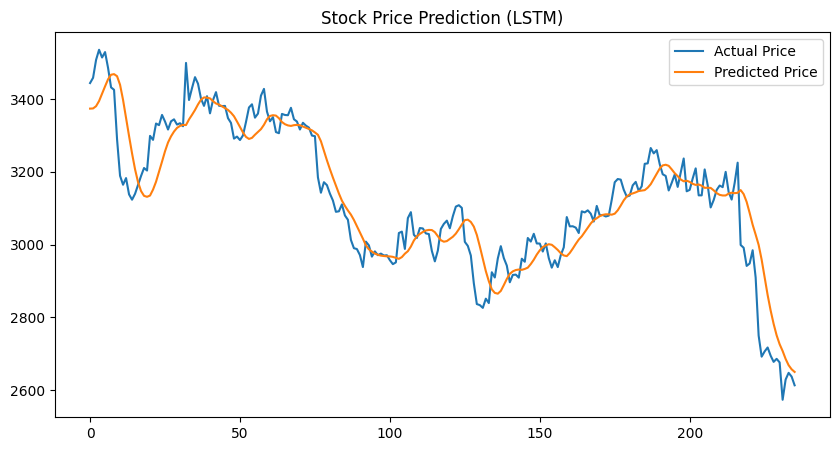

In [15]:
plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label='Actual Price')
plt.plot(predictions, label='Predicted Price')
plt.legend()
plt.title('Stock Price Prediction (LSTM)')
plt.show()

In [16]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print("RMSE:", rmse)

RMSE: 76.1112411378997


In [17]:
mean_price = np.mean(y_test_actual)
rmse_percentage = (rmse / mean_price) * 100

print("RMSE %:", rmse_percentage)

RMSE %: 2.4327859337491318


In [18]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test_actual, predictions)
print("MAE:", mae)

MAE: 56.15832829879502


In [19]:
import numpy as np

mape = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100
print("MAPE:", mape)

MAPE: 1.819297524116254


In [20]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test_actual, predictions)
print("R2 Score:", r2)

R2 Score: 0.8510659879839371


In [21]:
direction_actual = np.sign(y_test_actual[1:] - y_test_actual[:-1])
direction_pred = np.sign(predictions[1:] - predictions[:-1])
direction_acc = np.mean(direction_actual == direction_pred) * 100
print("Directional Accuracy:", direction_acc)

Directional Accuracy: 48.93617021276596


In [ ]:
#MODEL 2 BIDIRECTIONAL LSTM